# **Visualizing World Model results** 

This notebook implements the analysis of the results obtained from our world model.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
from jepacartpole.models import VAE, JEPAPredictor
from jepacartpole.config import ConfigVAE, ConfigJEPA

# loading VAE
vae_config = ConfigVAE()
vae = VAE(vae_config).to(DEVICE)
vae.load_state_dict(torch.load('../checkpoints/vae.pth', weights_only=False, map_location=DEVICE))

# loading jepa
jepa_config = ConfigJEPA()
jepa = JEPAPredictor(jepa_config).to(DEVICE)
jepa.load_state_dict(torch.load('../checkpoints/jepa_predictor.pth', weights_only=False, map_location=DEVICE)['model_state_dict'])
# torch.load('../checkpoints/jepa_predictor.pth', weights_only=False, map_location=DEVICE).keys()

<All keys matched successfully>

## 1. Visualizing Trajectory on Latent Space with PCA

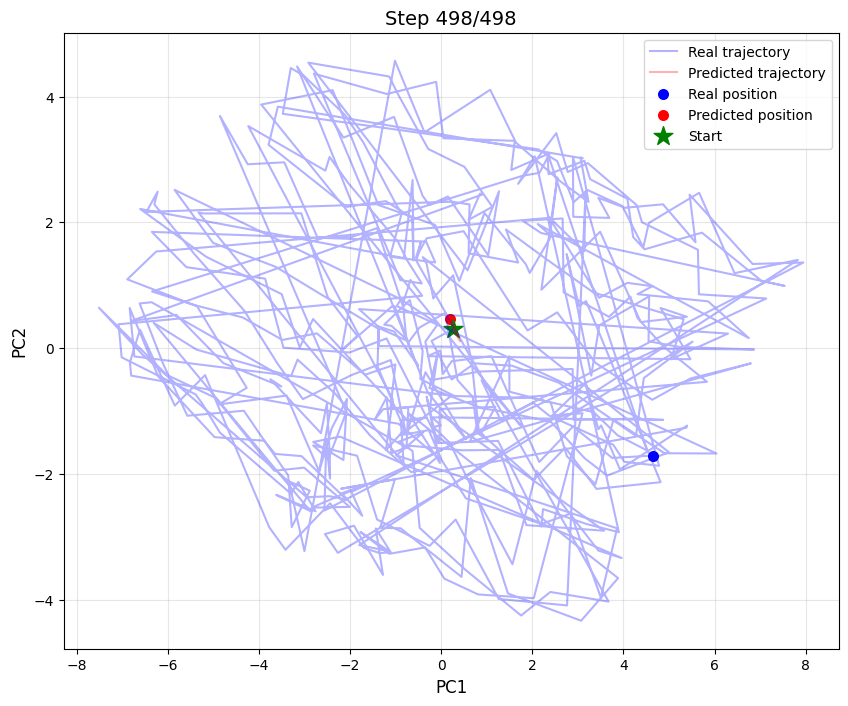

In [ ]:
import h5py
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set to evaluation mode
jepa.eval()
vae.eval()

# Get a test episode
test_episode_idx = 0
with h5py.File('../data/jepa/jepa.h5', 'r') as h5f:
    episode_length = h5f[f'episode_{test_episode_idx}_length'][()]
    z_real_full = h5f['z'][test_episode_idx, :episode_length]
    actions = h5f['actions'][test_episode_idx, :episode_length]
    
    # Convert to tensors
    z_real_full = torch.from_numpy(z_real_full).float()
    actions = torch.from_numpy(actions).float()

# Generate predicted trajectory
z_predicted = [z_real_full[0]]  # Start with real first latent

with torch.no_grad():
    for t in range(len(actions) - 1):
        z_t = z_predicted[-1].to(DEVICE)
        action_t = actions[t].to(DEVICE)
        
        # Predict next latent
        z_next_pred = jepa(z_t.unsqueeze(0), action_t.unsqueeze(0))
        z_predicted.append(z_next_pred.squeeze().cpu())

z_predicted = torch.stack(z_predicted)

# Decode latents to images
with torch.no_grad():
    # Decode real latents
    real_frames = []
    for z in z_real_full:
        z = z.unsqueeze(0).to(DEVICE)
        img = vae.decoder(z)  # Assuming decoder method
        real_frames.append(img.squeeze(0).cpu())
    
    # Decode reconstructed latents (real latents through VAE)
    reconstructed_frames = []
    for z in z_real_full:
        z = z.unsqueeze(0).to(DEVICE)
        img = vae.decoder(z)
        reconstructed_frames.append(img.squeeze(0).cpu())
    
    # Decode predicted latents
    predicted_frames = []
    for z in z_predicted:
        z = z.unsqueeze(0).to(DEVICE)
        img = vae.decoder(z)
        predicted_frames.append(img.squeeze(0).cpu())

# Convert to numpy for plotting
real_frames = torch.stack(real_frames).numpy()
reconstructed_frames = torch.stack(reconstructed_frames).numpy()
predicted_frames = torch.stack(predicted_frames).numpy()

# Normalize images if needed (assuming they're in [-1, 1] or [0, 1])
def normalize_image(img):
    if img.min() < 0:  # If in [-1, 1] range
        img = (img + 1) / 2
    return np.clip(img, 0, 1)

# Create the animation
def create_frame_gallery(num_frames=100, frames_per_row=5):
    """
    Create a scrolling gallery of real, reconstructed, and predicted frames
    
    Args:
        num_frames: Number of frames to display
        frames_per_row: How many timesteps to show per row
    """
    
    # Limit number of frames if needed
    num_frames = min(num_frames, len(real_frames))
    
    # Create figure
    fig, axes = plt.subplots(3, frames_per_row, figsize=(15, 9))
    fig.suptitle('Frame Prediction Gallery: Real | Reconstructed | Predicted', 
                 fontsize=16, y=0.98)
    
    # Keep track of all images for updating
    imgs = []
    
    # Initial setup
    for row, (frame_type, color) in enumerate([('Real', 'blue'), 
                                                ('Reconstructed', 'green'), 
                                                ('Predicted', 'red')]):
        for col in range(frames_per_row):
            ax = axes[row, col]
            
            if col == 0:
                # Add row label
                ax.set_ylabel(frame_type, fontsize=12, rotation=0, 
                            labelpad=20, color=color)
            
            # Hide axes
            ax.set_xticks([])
            ax.set_yticks([])
            
            # Add frame number at top
            idx = col
            if idx < num_frames:
                ax.set_title(f't={idx}', fontsize=10)
                
                # Display appropriate frame
                if row == 0:
                    img_display = normalize_image(real_frames[idx].transpose(1, 2, 0))
                elif row == 1:
                    img_display = normalize_image(reconstructed_frames[idx].transpose(1, 2, 0))
                else:
                    img_display = normalize_image(predicted_frames[idx].transpose(1, 2, 0))
                
                im = ax.imshow(img_display)
                imgs.append(im)
            else:
                # Empty frame
                ax.set_facecolor('lightgray')
    
    plt.tight_layout()
    
    # Animation function to scroll through frames
    def animate(frame):
        # Calculate which frames to show
        start_idx = frame
        end_idx = min(start_idx + frames_per_row, num_frames)
        
        # Update each image
        img_idx = 0
        for row in range(3):
            for col in range(frames_per_row):
                idx = start_idx + col
                
                if idx < num_frames:
                    # Update frame number
                    axes[row, col].set_title(f't={idx}', fontsize=10)
                    
                    # Update image
                    if row == 0:
                        img_data = normalize_image(real_frames[idx].transpose(1, 2, 0))
                    elif row == 1:
                        img_data = normalize_image(reconstructed_frames[idx].transpose(1, 2, 0))
                    else:
                        img_data = normalize_image(predicted_frames[idx].transpose(1, 2, 0))
                    
                    imgs[img_idx].set_array(img_data)
                    axes[row, col].set_visible(True)
                else:
                    # Hide axes beyond available frames
                    axes[row, col].set_visible(False)
                
                img_idx += 1
        
        return imgs
    
    # Create animation
    total_frames = max(0, num_frames - frames_per_row + 1)
    anim = FuncAnimation(fig, animate, frames=total_frames, 
                        interval=200, blit=True, repeat=True)
    
    return anim

# Alternative: Create a vertical scrolling version (video-like)
def create_video_style_gallery(num_frames=100, cols=3):
    """
    Create a video-style comparison with 3 columns: Real, Reconstructed, Predicted
    """
    num_frames = min(num_frames, len(real_frames))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Frame Prediction: Real | Reconstructed | Predicted', 
                 fontsize=14)
    
    # Hide axes
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Set titles
    axes[0].set_title('Real Frame', fontsize=12)
    axes[1].set_title('Reconstructed', fontsize=12)
    axes[2].set_title('Predicted', fontsize=12)
    
    # Initialize with first frame
    imgs = []
    for i, frames in enumerate([real_frames, reconstructed_frames, predicted_frames]):
        img_data = normalize_image(frames[0].transpose(1, 2, 0))
        im = axes[i].imshow(img_data)
        imgs.append(im)
    
    # Add step counter
    step_text = fig.text(0.5, 0.02, 'Step: 0', ha='center', fontsize=12)
    
    def animate(frame):
        idx = min(frame, num_frames - 1)
        
        # Update each image
        for i, frames in enumerate([real_frames, reconstructed_frames, predicted_frames]):
            img_data = normalize_image(frames[idx].transpose(1, 2, 0))
            imgs[i].set_array(img_data)
        
        # Update step counter
        step_text.set_text(f'Step: {idx}/{num_frames-1}')
        
        return imgs + [step_text]
    
    anim = FuncAnimation(fig, animate, frames=num_frames, 
                        interval=100, blit=True, repeat=True)
    
    return anim

# Generate and display the gallery
print("Creating Frame Prediction Gallery...")

# Option 1: Gallery view with multiple timesteps
anim_gallery = create_frame_gallery(num_frames=30, frames_per_row=5)
# HTML(anim_gallery.to_html5_video())

# Option 2: Video-style view (comment out if you prefer the gallery)
# anim_video = create_video_style_gallery(num_frames=50)
# HTML(anim_video.to_html5_video())

# Optional: Save the animation
# anim_gallery.save('frame_prediction_gallery.mp4', writer='ffmpeg', fps=5)

# Frame Prediction Gallery

Creating Frame Prediction Gallery...


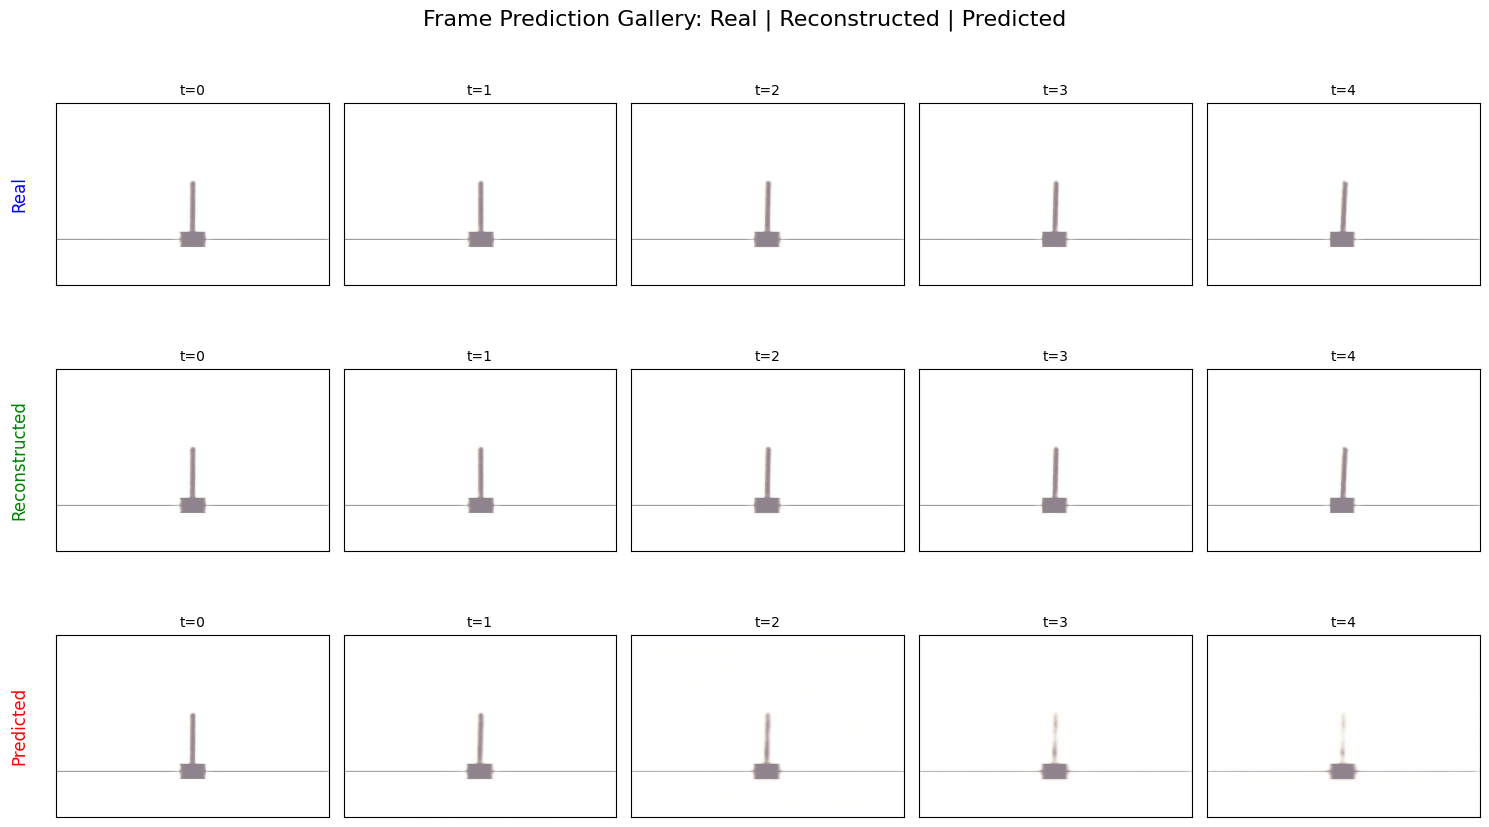

In [17]:
import h5py
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Set to evaluation mode
jepa.eval()
vae.eval()

# Get a test episode
test_episode_idx = 0
with h5py.File('../data/jepa/jepa.h5', 'r') as h5f:
    episode_length = h5f[f'episode_{test_episode_idx}_length'][()]
    z_real_full = h5f['z'][test_episode_idx, :episode_length]
    actions = h5f['actions'][test_episode_idx, :episode_length]
    
    # Convert to tensors
    z_real_full = torch.from_numpy(z_real_full).float()
    actions = torch.from_numpy(actions).float()

# Generate predicted trajectory
z_predicted = [z_real_full[0]]  # Start with real first latent

with torch.no_grad():
    for t in range(len(actions) - 1):
        z_t = z_predicted[-1].to(DEVICE)
        action_t = actions[t].to(DEVICE)
        
        # Predict next latent
        z_next_pred = jepa(z_t.unsqueeze(0), action_t.unsqueeze(0))
        z_predicted.append(z_next_pred.squeeze().cpu())

z_predicted = torch.stack(z_predicted)

# Decode latents to images
with torch.no_grad():
    # Decode real latents
    real_frames = []
    for z in z_real_full:
        z = z.unsqueeze(0).to(DEVICE)
        img = vae.decode(z)  # Assuming decoder method
        real_frames.append(img.squeeze(0).cpu())
    
    # Decode reconstructed latents (real latents through VAE)
    reconstructed_frames = []
    for z in z_real_full:
        z = z.unsqueeze(0).to(DEVICE)
        img = vae.decode(z)
        reconstructed_frames.append(img.squeeze(0).cpu())
    
    # Decode predicted latents
    predicted_frames = []
    for z in z_predicted:
        z = z.unsqueeze(0).to(DEVICE)
        img = vae.decode(z)
        predicted_frames.append(img.squeeze(0).cpu())

# Convert to numpy for plotting
real_frames = torch.stack(real_frames).numpy()
reconstructed_frames = torch.stack(reconstructed_frames).numpy()
predicted_frames = torch.stack(predicted_frames).numpy()

# Normalize images if needed (assuming they're in [-1, 1] or [0, 1])
def normalize_image(img):
    if img.min() < 0:  # If in [-1, 1] range
        img = (img + 1) / 2
    return np.clip(img, 0, 1)

# Create the animation
def create_frame_gallery(num_frames=100, frames_per_row=5):
    """
    Create a scrolling gallery of real, reconstructed, and predicted frames
    
    Args:
        num_frames: Number of frames to display
        frames_per_row: How many timesteps to show per row
    """
    
    # Limit number of frames if needed
    num_frames = min(num_frames, len(real_frames))
    
    # Create figure
    fig, axes = plt.subplots(3, frames_per_row, figsize=(15, 9))
    fig.suptitle('Frame Prediction Gallery: Real | Reconstructed | Predicted', 
                 fontsize=16, y=0.98)
    
    # Keep track of all images for updating
    imgs = []
    
    # Initial setup
    for row, (frame_type, color) in enumerate([('Real', 'blue'), 
                                                ('Reconstructed', 'green'), 
                                                ('Predicted', 'red')]):
        for col in range(frames_per_row):
            ax = axes[row, col]
            
            if col == 0:
                # Add row label with rotation
                ax.set_ylabel(frame_type, fontsize=12, rotation=90, 
                            labelpad=20, color=color)
            
            # Hide axes
            ax.set_xticks([])
            ax.set_yticks([])
            
            # Add frame number at top
            idx = col
            if idx < num_frames:
                ax.set_title(f't={idx}', fontsize=10)
                
                # Display appropriate frame
                if row == 0:
                    img_display = normalize_image(real_frames[idx].transpose(1, 2, 0))
                elif row == 1:
                    img_display = normalize_image(reconstructed_frames[idx].transpose(1, 2, 0))
                else:
                    img_display = normalize_image(predicted_frames[idx].transpose(1, 2, 0))
                
                im = ax.imshow(img_display)
                imgs.append(im)
            else:
                # Empty frame
                ax.set_facecolor('lightgray')
    
    plt.tight_layout()
    
    # Animation function to scroll through frames
    def animate(frame):
        # Calculate which frames to show
        start_idx = frame
        end_idx = min(start_idx + frames_per_row, num_frames)
        
        # Update each image
        img_idx = 0
        for row in range(3):
            for col in range(frames_per_row):
                idx = start_idx + col
                
                if idx < num_frames:
                    # Update frame number
                    axes[row, col].set_title(f't={idx}', fontsize=10)
                    
                    # Update image
                    if row == 0:
                        img_data = normalize_image(real_frames[idx].transpose(1, 2, 0))
                    elif row == 1:
                        img_data = normalize_image(reconstructed_frames[idx].transpose(1, 2, 0))
                    else:
                        img_data = normalize_image(predicted_frames[idx].transpose(1, 2, 0))
                    
                    imgs[img_idx].set_array(img_data)
                    axes[row, col].set_visible(True)
                else:
                    # Hide axes beyond available frames
                    axes[row, col].set_visible(False)
                
                img_idx += 1
        
        return imgs
    
    # Create animation
    total_frames = max(0, num_frames - frames_per_row + 1)
    anim = FuncAnimation(fig, animate, frames=total_frames, 
                        interval=200, blit=True, repeat=True)
    
    return anim

# Generate and display the gallery
print("Creating Frame Prediction Gallery...")

# Option 1: Gallery view with multiple timesteps
anim_gallery = create_frame_gallery(num_frames=30, frames_per_row=5)
# HTML(anim_gallery.to_html5_video())

# Action Importance Analysis

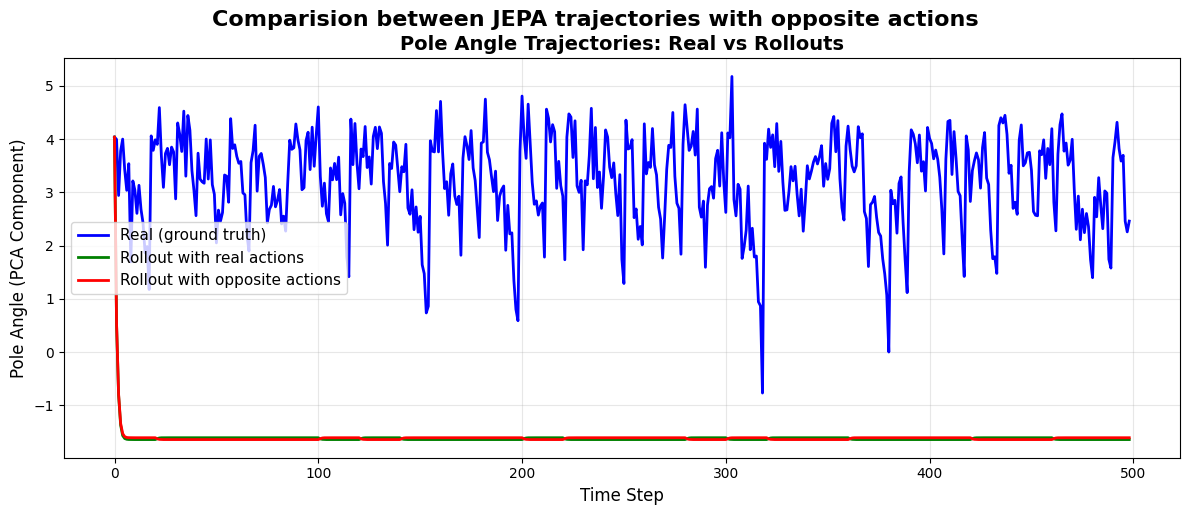

In [24]:
import h5py
import matplotlib.pyplot as plt
import torch
import numpy as np
from sklearn.decomposition import PCA

# Set to evaluation mode
jepa.eval()
vae.eval()

# Get a test episode
test_episode_idx = 0
with h5py.File('../data/jepa/jepa.h5', 'r') as h5f:
    episode_length = h5f[f'episode_{test_episode_idx}_length'][()]
    z_real_full = h5f['z'][test_episode_idx, :episode_length]
    actions = h5f['actions'][test_episode_idx, :episode_length]
    
    # Convert to tensors
    z_real_full = torch.from_numpy(z_real_full).float()
    actions = torch.from_numpy(actions).float()

# Run two rollouts
def rollout_with_actions(action_modifier=None):
    """
    Run a rollout with modified actions
    action_modifier: function that modifies actions (e.g., negate for opposite)
    """
    z_rollout = [z_real_full[0]]  # Start with real first latent
    
    with torch.no_grad():
        for t in range(len(actions) - 1):
            z_t = z_rollout[-1].to(DEVICE)
            action_t = actions[t].to(DEVICE)
            
            # Modify action if modifier provided
            if action_modifier is not None:
                action_t = action_modifier(action_t)
            
            # Predict next latent
            z_next_pred = jepa(z_t.unsqueeze(0), action_t.unsqueeze(0))
            z_rollout.append(z_next_pred.squeeze().cpu())
    
    return torch.stack(z_rollout)

# Run rollout with real actions
z_rollout_real = rollout_with_actions()

# Run rollout with opposite actions
def opposite_action(action):
    return (action + 1) % 2  # Negate the action (assuming binary actions 0/1)

z_rollout_opposite = rollout_with_actions(opposite_action)

# Use PCA to find the latent dimension that best captures the pole angle
def extract_pole_angle_via_pca(z_real, z_rollout1, z_rollout2):
    """
    Use PCA to find the latent dimension that best captures the pole angle
    """
    # Combine all trajectories
    all_z = torch.cat([z_real, z_rollout1, z_rollout2], dim=0).numpy()
    
    # Fit PCA
    pca = PCA(n_components=3)
    pca_result = pca.fit_transform(all_z)
    
    # The pole angle should be captured by the first principal component
    # that shows divergence between rollouts
    n_real = len(z_real)
    n_rollout1 = len(z_rollout1)
    
    # Return the first PC for each trajectory
    return (pca_result[:n_real, 0], 
            pca_result[n_real:n_real+n_rollout1, 0],
            pca_result[n_real+n_rollout1:, 0])

# Extract pole angles using PCA
real_angles, rollout_real_angles, rollout_opposite_angles = extract_pole_angle_via_pca(
    z_real_full, z_rollout_real, z_rollout_opposite
)

# Create the visualization
fig, axes = plt.subplots(1, 1, figsize=(12, 5))

# Plot 1: Pole angle over time for all three trajectories
ax1 = axes#[0]
time_steps = np.arange(len(real_angles))

ax1.plot(time_steps, real_angles, 'b-', linewidth=2, label='Real (ground truth)')
ax1.plot(time_steps, rollout_real_angles, 'g-', linewidth=2, label='Rollout with real actions')
ax1.plot(time_steps, rollout_opposite_angles, 'r-', linewidth=2, label='Rollout with opposite actions')

ax1.set_xlabel('Time Step', fontsize=12)
ax1.set_ylabel('Pole Angle (PCA Component)', fontsize=12)
ax1.set_title('Pole Angle Trajectories: Real vs Rollouts', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=11)
ax1.grid(True, alpha=0.3)

# Add annotation to highlight divergence
if len(rollout_real_angles) > 10 and len(rollout_opposite_angles) > 10:
    # Find where trajectories start to diverge significantly
    mid_point = len(time_steps) // 2
    if mid_point < len(time_steps):
        # Check if there's actual divergence
        divergence = np.abs(rollout_real_angles - rollout_opposite_angles)
        if np.max(divergence) > 0.1 * np.std(real_angles):
            ax1.axvline(x=mid_point, color='gray', linestyle='--', alpha=0.5, 
                       label='Divergence point')
            ax1.text(mid_point + 1, ax1.get_ylim()[1] * 0.9, 
                    'Actions cause\ndivergence', fontsize=10, 
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Plot 2: Difference between rollouts and real trajectory
# ax2 = axes[1]

# # Make sure lengths match
# min_len = min(len(rollout_real_angles), len(real_angles))
# diff_real = rollout_real_angles[:min_len] - real_angles[:min_len]

# min_len_opp = min(len(rollout_opposite_angles), len(real_angles))
# diff_opposite = rollout_opposite_angles[:min_len_opp] - real_angles[:min_len_opp]

# ax2.plot(time_steps[:len(diff_real)], diff_real, 'g-', linewidth=2, 
#         label='Real actions - Ground truth')
# ax2.plot(time_steps[:len(diff_opposite)], diff_opposite, 'r-', linewidth=2, 
#         label='Opposite actions - Ground truth')

# ax2.set_xlabel('Time Step', fontsize=12)
# ax2.set_ylabel('Angle Difference', fontsize=12)
# ax2.set_title('Deviation from Ground Truth', fontsize=14, fontweight='bold')
# ax2.legend(loc='best', fontsize=11)
# ax2.grid(True, alpha=0.3)
# ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Add shaded region to highlight divergence
if len(diff_opposite) > 10:
    max_diff = np.max(np.abs(diff_opposite))
    if max_diff > 0:
        ax2.fill_between(time_steps[:len(diff_opposite)], 
                         -max_diff/2, max_diff/2, 
                         alpha=0.1, color='red', label='Divergence region')

plt.tight_layout()

# Add overall title with conclusion
fig.suptitle('Comparision between JEPA trajectories with opposite actions', 
             fontsize=16, fontweight='bold', y=1.02)

plt.show()